# Lognormal Distribution

A variable X is **lognormally distributed** if Y = ln(X) is normally distributed. It models positive, right-skewed data that arises from multiplicative processes — particle sizes, incomes, failure times, stock prices.

| Property | Value |
|---|---|
| **Parameters** | σ (shape = std of log), m (scale = median), θ (location) |
| **Support** | (θ, +∞) |
| **PDF** | f(x) = exp(−(ln(x)−μ)²/2σ²) / (xσ√2π), where μ=ln(m) |
| **Mean** | m · exp(σ²/2) |
| **Median** | m |
| **Mode** | m · exp(−σ²) |
| **Skewness** | Right-skewed; increases with σ |
| **Relationship** | ln(X) ~ N(ln(m), σ²) |
| **Estimation** | μ̂ = mean(ln x), σ̂ = std(ln x), m̂ = exp(μ̂) |
| **Use cases** | Failure times, incomes, particle sizes, stock returns |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

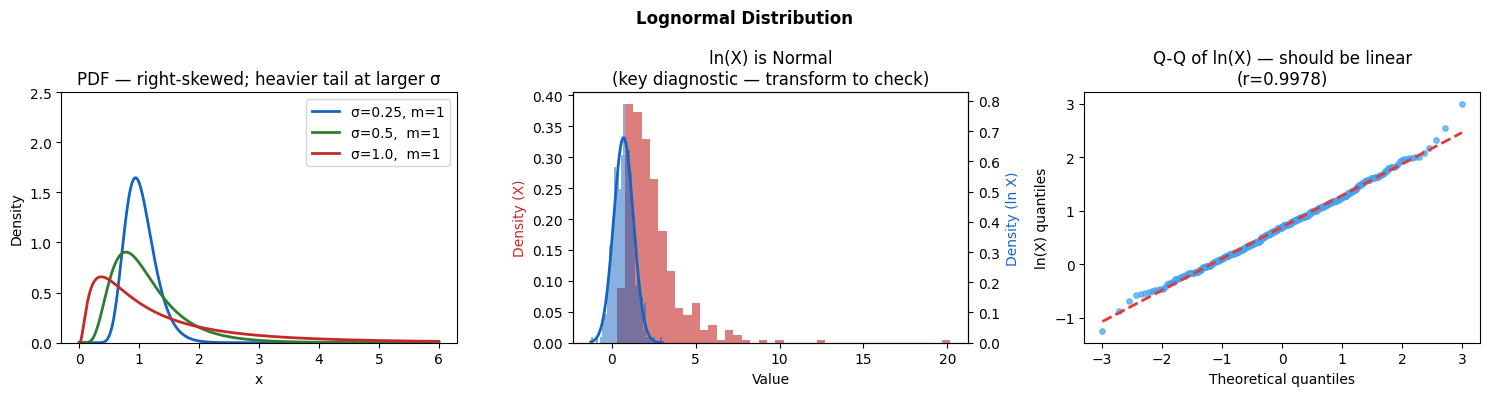

True:  σ=0.6, m=2.0
MLE:   σ̂=0.588, m̂=2.008
Mean of X:   true=2.394, sample=2.406


In [2]:
x = np.linspace(0.001, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Lognormal Distribution', fontsize=12, fontweight='bold')

# PDF — scipy lognorm: s=sigma, scale=m (median)
for sigma, m, color, label in [(0.25, 1, '#1565C0', 'σ=0.25, m=1'),
                                (0.5,  1, '#2E7D32', 'σ=0.5,  m=1'),
                                (1.0,  1, '#C62828', 'σ=1.0,  m=1')]:
    axes[0].plot(x, stats.lognorm(s=sigma, scale=m).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed; heavier tail at larger σ')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2.5)
axes[0].legend()

# Log-transform reveals Normal
np.random.seed(42)
sigma_true, m_true = 0.6, 2.0
sample = stats.lognorm(s=sigma_true, scale=m_true).rvs(500)
log_sample = np.log(sample)

axes[1].hist(sample, bins=40, density=True, color='#C62828', alpha=0.6, label='X (lognormal)')
ax2 = axes[1].twinx()
ax2.hist(log_sample, bins=40, density=True, color='#1565C0', alpha=0.5, label='ln(X) (normal)')
x_norm = np.linspace(log_sample.min(), log_sample.max(), 200)
ax2.plot(x_norm, stats.norm(log_sample.mean(), log_sample.std()).pdf(x_norm),
         color='#1565C0', linewidth=2)
axes[1].set_title('ln(X) is Normal\n(key diagnostic — transform to check)')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('Density (X)', color='#C62828')
ax2.set_ylabel('Density (ln X)', color='#1565C0')

# Q-Q on log scale
(osm, osr), (slope, intercept, r) = stats.probplot(log_sample, dist='norm')
axes[2].scatter(osm, osr, color='#42A5F5', s=15, alpha=0.7)
axes[2].plot([min(osm), max(osm)], [slope*min(osm)+intercept, slope*max(osm)+intercept],
             color='#E53935', linewidth=2, linestyle='--')
axes[2].set_title(f'Q-Q of ln(X) — should be linear\n(r={r:.4f})')
axes[2].set_xlabel('Theoretical quantiles'); axes[2].set_ylabel('ln(X) quantiles')

plt.tight_layout()
plt.show()

# MLE estimation
sigma_hat = log_sample.std()
m_hat = np.exp(log_sample.mean())
print(f"True:  σ={sigma_true}, m={m_true}")
print(f"MLE:   σ̂={sigma_hat:.3f}, m̂={m_hat:.3f}")
print(f"Mean of X:   true={m_true*np.exp(sigma_true**2/2):.3f}, "
      f"sample={sample.mean():.3f}")

## Key Takeaways

| | |
|---|---|
| **Defining feature** | X is lognormal ⟺ ln(X) is Normal |
| **Shape σ** | Controls tail heaviness; larger σ → more right-skewed |
| **Mean > Median > Mode** | Always true (right-skewed); use median for central tendency |
| **Multiplicative process** | Product of many positive factors → Lognormal (CLT on log scale) |
| **Estimation** | Fit Normal to ln(x); back-transform |
| **vs Weibull** | Both model failure times; Weibull is more flexible for hazard shapes |
| **Check** | Plot histogram of ln(x) — should look Normal; Q-Q of ln(x) should be linear |